In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(105, 4) (45, 4)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for k in [1, 3, 5, 11, 25, 51]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"k={k:3d}  accuracy={accuracy_score(y_test, y_pred):.4f}")

k=  1  accuracy=1.0000
k=  3  accuracy=1.0000
k=  5  accuracy=1.0000
k= 11  accuracy=1.0000
k= 25  accuracy=1.0000
k= 51  accuracy=0.9556


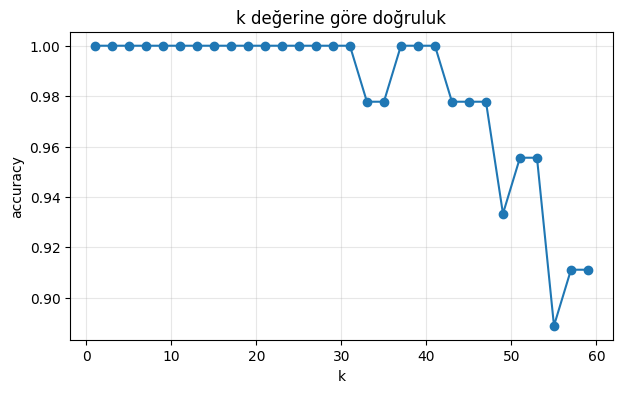

In [ ]:
import matplotlib.pyplot as plt

ks = range(1, 61, 2)
scores = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(7, 4))
plt.plot(list(ks), scores, marker='o')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.title('k değerine göre doğruluk')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklenmiş veriyle:")
for k in [1, 3, 5, 11, 25, 51]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"k={k:3d}  accuracy={accuracy_score(y_test, y_pred):.4f}")

Ölçeklenmiş veriyle:
k=  1  accuracy=0.9778
k=  3  accuracy=1.0000
k=  5  accuracy=1.0000
k= 11  accuracy=1.0000
k= 25  accuracy=0.9778
k= 51  accuracy=0.8444


- Grafikteki basamaklar tek tek çiçeklere denk geliyor: test setinde 45 örnek
  var, yani bir çiçek = 1/45 = 0.0222. Y eksenindeki tüm değerler bunun katı.
  Bu da iki model arasındaki 0.02'lik farkın aslında "bir çiçek" demek olduğunu
  gösteriyor — bu kadar küçük bir test setinde o farka anlam yüklememek lazım.

- Ölçekleme deneyi beklediğimin tersini verdi: k=1, 25 ve 51'de accuracy DÜŞTÜ
  (k=51'de 0.9556'dan 0.8444'e). Sebebi, Iris'te özelliklerin eşit derecede
  faydalı olmaması. Petal ölçümleri türleri net ayırıyor, sepal ölçümleri
  karışık. Ham veride petal'in aralığı daha geniş olduğu için mesafe hesabında
  zaten ağır basıyordu ve bu tesadüfen doğru olanı yapıyordu. Ölçekleyince
  gürültülü olan sepal'i petal ile eşitlemiş oldum.
  Çıkarım: ölçekleme özelliklerin ÖLÇEK farkını kaldırır, ÖNEM farkını değil.
  Farklı birimlerdeki özelliklerde (kolesterol vs yaş) zorunlu, ama Iris'te
  dördü de aynı birimde olduğu için düzeltilecek bir bozukluk yoktu.